# Jeans Code Benchmark

This notebook visualizes artifacts generated by `scripts/benchmark_jeans_codes.py`.
Run the CLI first, then execute the cells below from the repository root.


In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import corner

ROOT = Path.cwd()
ART = ROOT / '..' / 'benchmarks' / 'jeans_comparison' / 'artifacts'
summaries = sorted(ART.glob('summary_*_n4000_seed*.json'))
# summaries

In [2]:
rows = []
loaded = []
for path in summaries:
    summary = json.loads(path.read_text())
    loaded.append(summary)
    for result in summary['results']:
        row = {
            'anisotropy': summary['anisotropy'],
            'engine': result['engine'],
            'status': result['status'],
            'sampling_seconds': result.get('sampling_seconds'),
            'prediction_seconds': result.get('prediction_seconds'),
            'acceptance_fraction': result.get('acceptance_fraction'),
        }
        for name, q in result.get('quantiles', {}).items():
            row[f'{name}_q50'] = q['q50']
        rows.append(row)

table = pd.DataFrame(rows)
table

,anisotropy,engine,status,sampling_seconds,prediction_seconds,acceptance_fraction,log10_rs_pc_q50,log10_rhos_Msunpc3_q50,log10_r_a_pc_q50
0,isotropic,jeanspy,ok,0.283168,0.000658,0.589583,3.086919,-1.950306,NaN
1,isotropic,jampy,ok,1.330892,0.002697,0.587500,3.109080,-1.984237,NaN
2,isotropic,agama,ok,62.424436,0.121429,0.595833,3.097452,-1.964646,NaN
3,isotropic,gravsphere2,skipped,NaN,NaN,NaN,NaN,NaN,NaN
4,isotropic,jeanspy,ok,0.274899,0.000426,0.575000,3.091697,-1.945093,NaN
5,isotropic,jeanspy-nuts,ok,6.943837,0.000442,NaN,3.004341,-1.812704,NaN
6,isotropic,jeanspy,ok,1.172684,0.000672,0.701852,3.143106,-2.030448,NaN
7,isotropic,jeanspy-nuts,ok,8.861098,0.000508,0.920238,3.135588,-2.022419,NaN
8,isotropic,jeanspy,ok,1.176669,0.000568,0.676852,3.015558,-1.856605,NaN
9,isotropic,jampy,ok,5.867744,0.002689,0.684259,3.001490,-1.837889,NaN


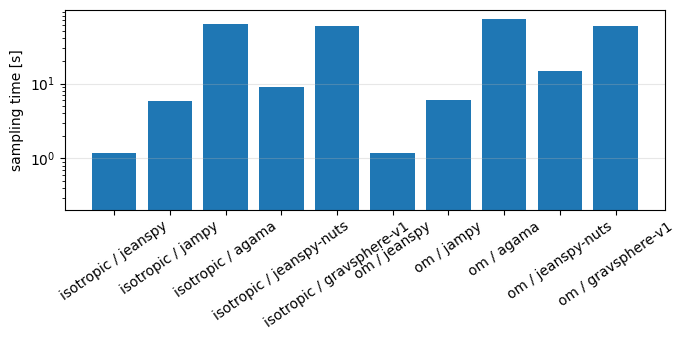

In [3]:
fig, ax = plt.subplots(figsize=(7, 3.5))
ok = table[table['status'] == 'ok'].copy()
labels = ok['anisotropy'] + ' / ' + ok['engine']
ax.bar(labels, ok['sampling_seconds'])
ax.set_yscale('log')
ax.set_ylabel('sampling time [s]')
ax.tick_params(axis='x', rotation=35)
ax.grid(True, axis='y', alpha=0.3)
fig.tight_layout()

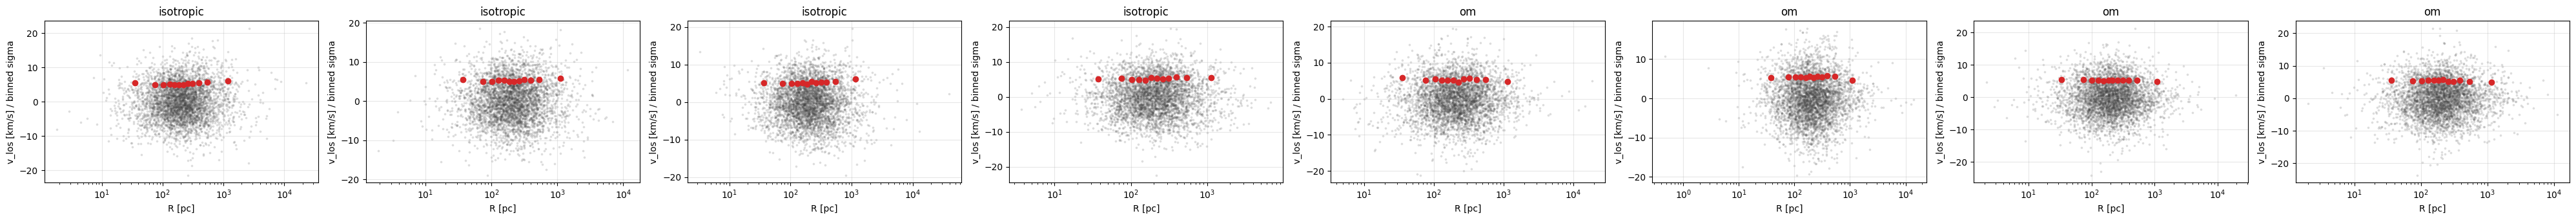

In [4]:
fig, axes = plt.subplots(1, len(loaded), figsize=(5 * len(loaded), 3.5), squeeze=False)
for ax, summary in zip(axes[0], loaded):
    mock = np.load(summary['mock']['path'])
    prof = np.load(summary['profile_path'])
    ax.scatter(mock['R_pc'], mock['vlos_kms'], s=3, alpha=0.12, color='0.25')
    ax.errorbar(prof['radius_pc'], prof['sigma_kms'], yerr=prof['sigma_err_kms'], fmt='o', color='tab:red')
    ax.set_xscale('log')
    ax.set_title(summary['anisotropy'])
    ax.set_xlabel('R [pc]')
    ax.set_ylabel('v_los [km/s] / binned sigma')
    ax.grid(True, alpha=0.3)
fig.tight_layout()

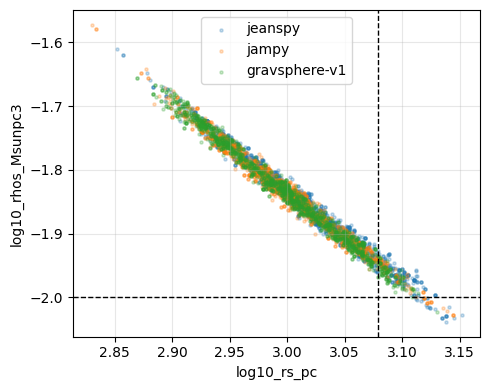

In [ ]:
def load_chain(summary, engine):
    result = next(r for r in summary['results'] if r['engine'] == engine and r['status'] == 'ok')
    data = np.load(result['posterior_path'])
    return data['flat_chain'], list(data['theta_names'])

summary = next((s for s in loaded if s['anisotropy'] == 'isotropic' and s.get('seed') == 62345), loaded[0])
fig, ax = plt.subplots(figsize=(5, 4))
for engine in ['jeanspy', 'jampy', 'agama', 'gravsphere-v1', 'jeanspy-nuts']:
    try:
        chain, names = load_chain(summary, engine)
    except StopIteration:
        continue
    ax.scatter(chain[:, 0], chain[:, 1], s=5, alpha=0.25, label=engine)
ax.axvline(np.log10(1200.0), color='k', lw=1, ls='--')
ax.axhline(np.log10(1e-2), color='k', lw=1, ls='--')
ax.set_xlabel(names[0])
ax.set_ylabel(names[1])
ax.legend()
ax.grid(True, alpha=0.3)
fig.tight_layout()

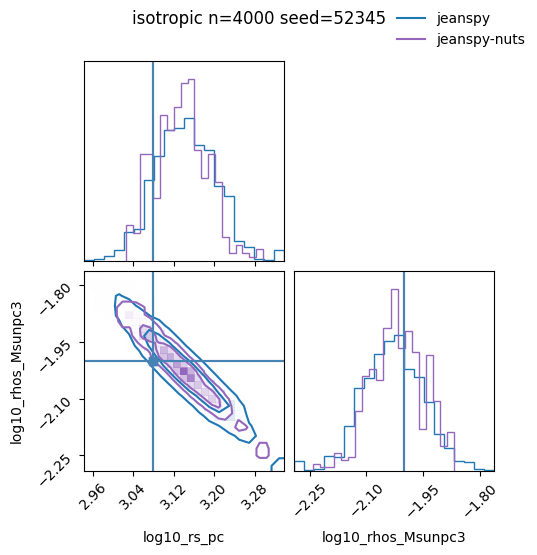

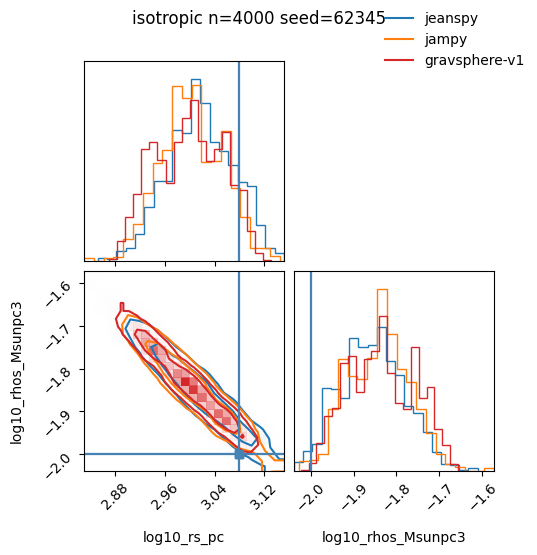

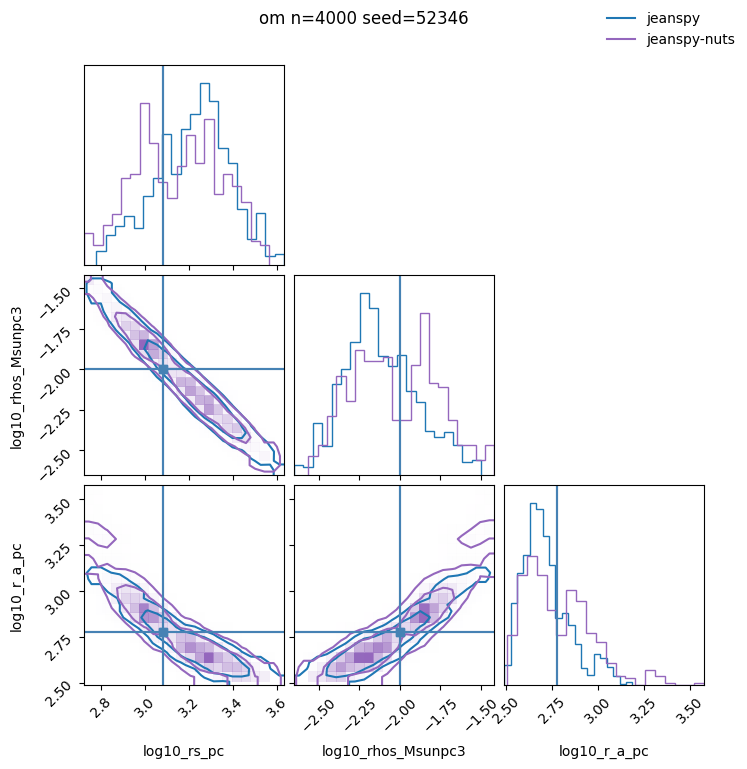

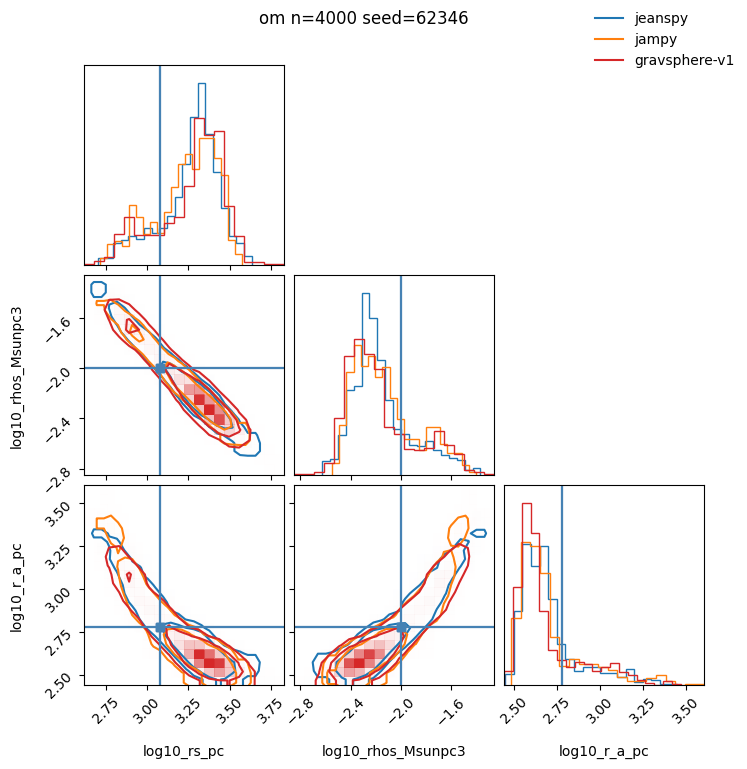

In [6]:
TRUE_THETA = {
    'log10_rs_pc': np.log10(1200.0),
    'log10_rhos_Msunpc3': np.log10(1e-2),
    'log10_r_a_pc': np.log10(600.0),
}
COLOR_MAP = {
    'jeanspy': 'C0',
    'jeanspy-nuts': 'C4',
    'jampy': 'C1',
    'agama': 'C2',
    'gravsphere-v1': 'C3',
}

def corner_overlay(summary, engines=None, max_samples=2000):
    results = [r for r in summary['results'] if r['status'] == 'ok']
    if engines is not None:
        wanted = set(engines)
        results = [r for r in results if r['engine'] in wanted]
    if not results:
        return None

    fig = None
    labels = None
    for result in results:
        data = np.load(result['posterior_path'])
        chain = np.asarray(data['flat_chain'])
        labels = list(data['theta_names'])
        if len(chain) > max_samples:
            rng = np.random.default_rng(123)
            chain = chain[rng.choice(len(chain), max_samples, replace=False)]
        fig = corner.corner(
            chain,
            labels=labels,
            truths=[TRUE_THETA.get(name) for name in labels],
            fig=fig,
            color=COLOR_MAP.get(result['engine']),
            plot_datapoints=False,
            fill_contours=False,
            levels=(0.68, 0.95),
            smooth=0.7,
            hist_kwargs={'density': True},
            label_kwargs={'fontsize': 10},
        )

    handles = [plt.Line2D([0], [0], color=COLOR_MAP.get(r['engine'], 'k'), label=r['engine']) for r in results]
    fig.legend(handles=handles, loc='upper right', frameon=False)
    fig.suptitle(f"{summary['anisotropy']} n={summary['n_stars']} seed={summary['seed']}", y=1.02)
    return fig

selected = [
    s for s in loaded
    if s.get('seed') in {52345, 52346, 62345, 62346}
]
for summary in selected:
    corner_overlay(summary)